
# Sprint 11


## Libraries used in this sprint

In [2]:
import pymysql
import pandas as pd
from sqlalchemy import create_engine
import cryptography
from sqlalchemy import inspect
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import scipy
print("OK")

OK


## Level 1

## SQL - Python connection with database from Sprint 4 >>> Task4

In [3]:
#My data
USER = "root"
PASSWORD = "Lazaro07!"
HOST = "localhost"
DB = "task4"
#Engine
engine = create_engine(f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}/{DB}")

### Getting tables names

In [4]:
insp = inspect(engine)
print(insp.get_table_names())

['active_ccards', 'all_users', 'companies', 'credit_cards', 'products', 'transaction_products', 'transactions']


### Reading tables using pandas

In [7]:
prod = pd.read_sql("SELECT * FROM task4.products", engine)
users = pd.read_sql("SELECT * FROM task4.all_users", engine)
comp = pd.read_sql("SELECT * FROM task4.companies", engine)
t_products = pd.read_sql("SELECT * FROM task4.transaction_products", engine)
transact = pd.read_sql("SELECT * FROM task4.transactions", engine)

In [9]:
prod.dtypes

id              str
product_name    str
price           str
colour          str
weight          str
warehouse_id    str
dtype: object

### Variables cleaning and transformation

In [15]:
# 1 Convertimos a fechas y calculamos la edad actual y la edad durante 
# la ultima transaction (dos nuevas variables numericas)
users['User_BD'] = pd.to_datetime(users['birth_date'], format='%b %d, %Y')
users['age'] = datetime.now().year - users['User_BD'].dt.year

#Calculamos la edad que tenia cada usuario en la ultima tranaccion
# Vinculamos os datos estén de las tablas user y transaction antes de restar
u_t = pd.merge(transact, users[['id', 'User_BD', 'country','Continent']], left_on='user_id', right_on='id')
u_t['age_at_transaction'] = (u_t['timestamp'] - u_t['User_BD']).dt.days // 365
# Convertimos a años (usando .days para obtener el total de días y dividiendo por los dias del year)

# Ordenamos por usuario y fecha de forma descendente
u_t = u_t.sort_values(by=['user_id', 'timestamp'], ascending=[True, False])

# Nos quedamos con la primera fila de cada usuario (la más reciente)
df_last_transaction = u_t.drop_duplicates(subset='user_id')
# Ahora u_t['age_at_transaction'] es la edad en su última compra


# 2. Convertir las columnas price y weight a tipo float
prod['Price'] = prod['price'].str.replace('$', '', regex=False).str.strip()
prod['Price'] = pd.to_numeric(prod['Price'], errors='coerce')
prod['Weight'] = pd.to_numeric(prod['weight'], errors='coerce')

# Convertimos declined a texto para que Seaborn lo trate como categoría
transact['Status'] = transact['declined'].map({0: 'Accepted', 1: 'Declined'})

In [17]:
prod.dtypes
#u_t.dtypes

id                  str
product_name        str
price               str
colour              str
weight              str
warehouse_id        str
Price           float64
Weight          float64
dtype: object

In [199]:
df_last_transaction

,id_x,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,Status,age_at_transaction,year,id_y,User_BD,country,Continent
0,1EDDC7AC-D3CA-440B-A048-3CBC692995CB,CcU-4856,b-2426,2024-11-15 14:48:20,254.46,0,"94, 96, 12",1,40.7070,-74.00550,Accepted,38.0,2024,1,1985-11-17,United States,America
26,AF624FF8-1AE7-4F54-9CAD-D630D44F6409,CcU-4793,b-2494,2024-10-05 14:24:36,335.87,0,"95, 14, 100, 41",10,37.3470,-121.88100,Accepted,40.0,2024,10,1984-04-30,United States,America
54,97BF01CF-4BB6-40B8-A952-95CC5B877239,CcU-4163,b-2290,2024-11-26 01:52:33,127.09,0,33,100,37.3306,-121.88400,Accepted,35.0,2024,100,1989-09-15,United States,America
86,0560CA2C-B5CF-4057-8339-A64CB4E5CC37,CcS-5581,b-2262,2024-11-27 08:38:35,69.16,0,"81, 8, 96",1000,51.4672,10.42810,Accepted,54.0,2024,1000,1970-05-17,Germany,Europe
103,488ABAA8-90F9-4C7F-8F5A-1FB5C84CE7F5,CcS-5582,b-2374,2024-10-01 15:00:19,356.94,0,"26, 89, 2, 65",1001,50.9080,10.19320,Accepted,30.0,2024,1001,1994-03-04,Germany,Europe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99905,E0C59135-9CC6-42BA-BE62-99CEF387EB06,CcS-5576,b-2458,2023-12-04 10:13:35,507.18,0,"5, 57, 40, 17",995,51.9890,5.75690,Accepted,61.0,2023,995,1962-09-03,Netherlands,Europe
99925,243FBD4A-7C7E-41D6-B2E0-71F78E8154C3,CcS-5577,b-2514,2024-06-23 07:33:38,494.79,0,"5, 82, 65, 86",996,51.0468,-114.07800,Accepted,54.0,2024,996,1970-03-22,Canada,America
99941,9B912F44-38FD-412B-8C74-86A3B7EECEDD,CcS-5578,b-2478,2024-12-21 07:57:32,326.23,0,"3, 33, 61",997,52.6029,4.93750,Accepted,26.0,2024,997,1998-04-24,Netherlands,Europe
99958,E0FDE35C-72E5-46FF-8F43-91D7A23CC314,CcS-5579,b-2254,2024-07-14 10:55:25,254.55,0,"87, 74",998,53.5385,-113.49000,Accepted,74.0,2024,998,1950-01-11,Canada,America


## Variables visualization:

### # 1. Una variable numérica

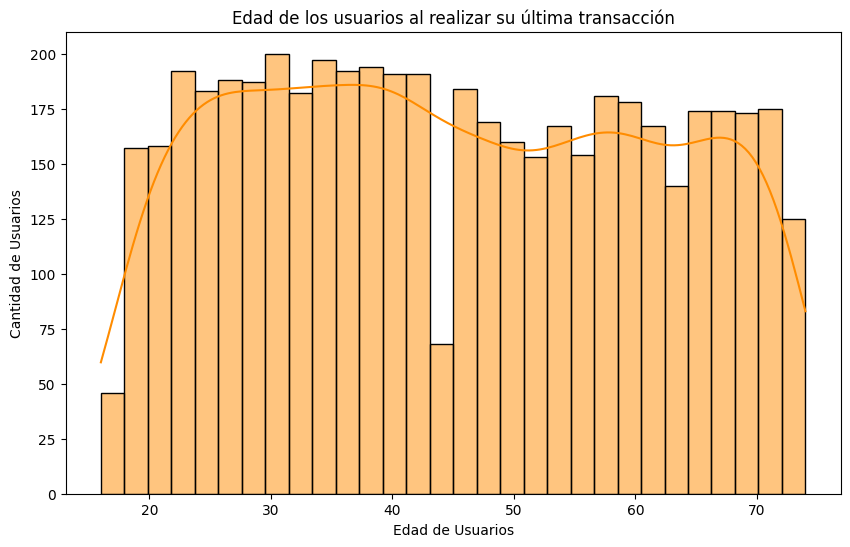

In [200]:
# 1. Una variable numérica (Histograma de usuarios por edad durante last transaction)
plt.figure(figsize=(10, 6))
sns.histplot(df_last_transaction['age_at_transaction'], bins=30, kde=True, color='darkorange')
plt.title('Edad de los usuarios al realizar su última transacción')
plt.xlabel('Edad de Usuarios')
plt.ylabel('Cantidad de Usuarios')
plt.show()

#### Interpretación: Los usuarios que realizan las compras tienen entre los 20 y 70 años. Aunque el numero de usuarios se distribuye de manera mas o menos uniforme entre las distintas edades, los mayores de 70, menores de 20 y los de 45 años aproximadamente, tienen una menor representación.

### # 2. Dos variables numériques

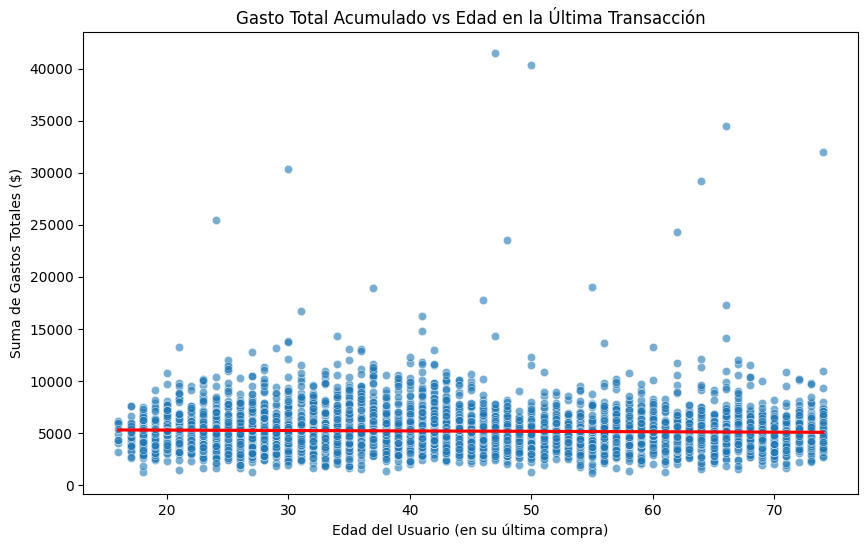

In [18]:
# Edad de ultima compra y gasto total por usuario
# Agrupamos la tabla de transacciones original para sacar el gasto total por usuario
# Usamos 'transact' porque contiene todas las operaciones, no solo la última
total_gasto_user = transact.groupby('user_id')['amount'].sum().reset_index()

# 2. Unimos el gasto total con la tabla que creaste de la última transacción
# 'df_last_transaction' ya tiene la columna 'age_at_transaction'
df_final = pd.merge(total_gasto_user, df_last_transaction[['user_id', 'age_at_transaction']], on='user_id')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x='age_at_transaction', y='amount', alpha=0.6)

# Añadimos una línea de regresión para ver la tendencia
sns.regplot(data=df_final, x='age_at_transaction', y='amount', scatter=False, color='red')

plt.title('Gasto Total Acumulado vs Edad en la Última Transacción')
plt.xlabel('Edad del Usuario (en su última compra)')
plt.ylabel('Suma de Gastos Totales ($)')
plt.show()

#### Interpretación: El gasto total (Hasta la ultima compra) de lo usuarios, se encuentra alrededor de los 5000 dolares, sin importar la edad al realizar las ultimas compras. 

### # 3. Una variable categorica

In [ ]:
#Generamos una consulta para seleccionar las columnas que necesitamos para la visualizacion
query = """
    SELECT 
        t.id,
        t.amount, 
        t.declined, 
        u.birth_date,
        u.Continent,
        u.id AS User_ID,
        t.timestamp
    FROM transactions t
    JOIN all_users u ON t.user_id = u.id
    JOIN transaction_products pt ON t.id = pt.transaction_id
    """

df_trans_users = pd.read_sql(query, engine)
df_trans_users

,id,amount,declined,birth_date,Continent,User_ID,timestamp
0,00D8F1C6-FF88-4E47-B26B-BC32AD4112C3,272.45,0,"Nov 17, 1985",America,1,2022-01-25 22:57:15
1,00D8F1C6-FF88-4E47-B26B-BC32AD4112C3,272.45,0,"Nov 17, 1985",America,1,2022-01-25 22:57:15
2,00D8F1C6-FF88-4E47-B26B-BC32AD4112C3,272.45,0,"Nov 17, 1985",America,1,2022-01-25 22:57:15
3,00D8F1C6-FF88-4E47-B26B-BC32AD4112C3,272.45,0,"Nov 17, 1985",America,1,2022-01-25 22:57:15
4,00D8F1C6-FF88-4E47-B26B-BC32AD4112C3,272.45,0,"Nov 17, 1985",America,1,2022-01-25 22:57:15
...,...,...,...,...,...,...,...
253386,F29FE48F-52EE-4B2D-AA9F-6407761C44C3,247.40,0,"Jan 26, 1995",Europe,999,2015-10-08 09:48:19
253387,F29FE48F-52EE-4B2D-AA9F-6407761C44C3,247.40,0,"Jan 26, 1995",Europe,999,2015-10-08 09:48:19
253388,F402C4A4-0A99-45CC-9CE0-864268639B9B,151.78,0,"Jan 26, 1995",Europe,999,2019-04-03 22:59:38
253389,F7EBFA5F-FFC1-4D0A-8C51-81657C8F2346,214.12,0,"Jan 26, 1995",Europe,999,2020-08-28 07:45:17


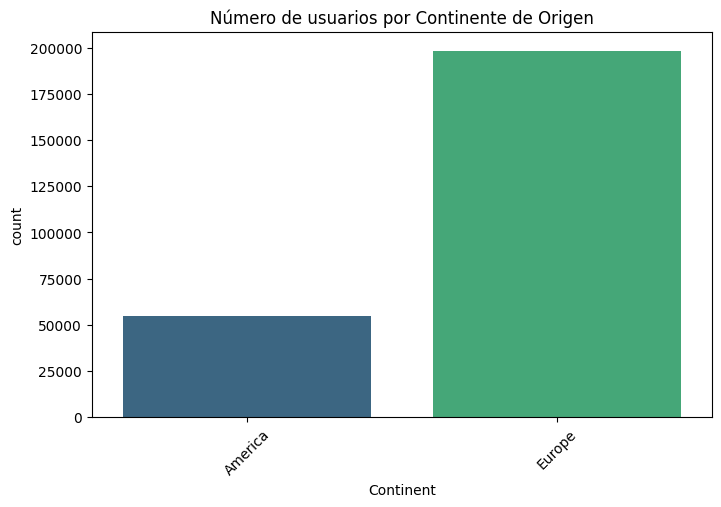

In [22]:
# 3. Gráfico de barras numero de usuarios por continente de origen
plt.figure(figsize=(8, 5))
sns.countplot(data=df_trans_users, x='Continent', palette='viridis', hue='Continent')
plt.xticks(rotation=45)
plt.title('Número de usuarios por Continente de Origen')
plt.show()

#### Interpretacion: Los usuarios tienen su origen mayoritariamente en Europa.

### #4. Una variable categórica y una numérica.

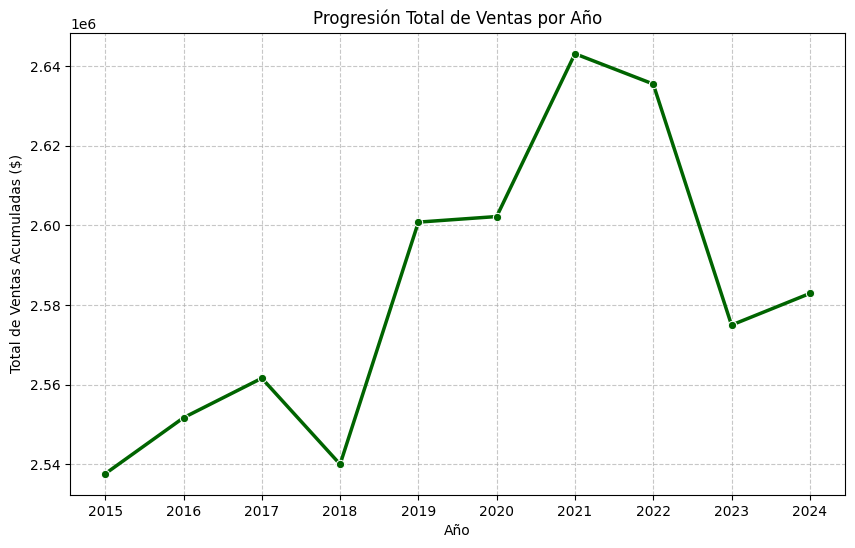

In [23]:
# Total de ventas acumuladas por año
# 1. Extraemos el año del timestamp
transact['year'] = transact['timestamp'].dt.year

# 2. Agrupamos por año y sumamos el importe de las ventas
# Usamos solo las transacciones aceptadas para ver ventas reales
sales_progression = transact[transact['Status'] == 'Accepted'].groupby('year')['amount'].sum().reset_index()

# 3. Creamos la gráfica de línea
plt.figure(figsize=(10, 6))
sns.lineplot(data=sales_progression, x='year', y='amount', marker='o', linewidth=2.5, color='darkgreen')
plt.title('Progresión Total de Ventas por Año')
plt.xlabel('Año')
plt.ylabel('Total de Ventas Acumuladas ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(sales_progression['year'])
plt.show()

#### Interpretación: La escala del eje y (Total de ventas), se encuentra ampliada para apreciar la variacion de las transacciones a lo largo del tiempo. Las ventas totales mostraron un descenso en 2018, 2023 y 2024. El pico de ventas asociado a los años 2019 a 2021, puede tener su explicación en el aumento de ventas online debido a la pandemia COVID 19.

### #5. Dos variables categoriques

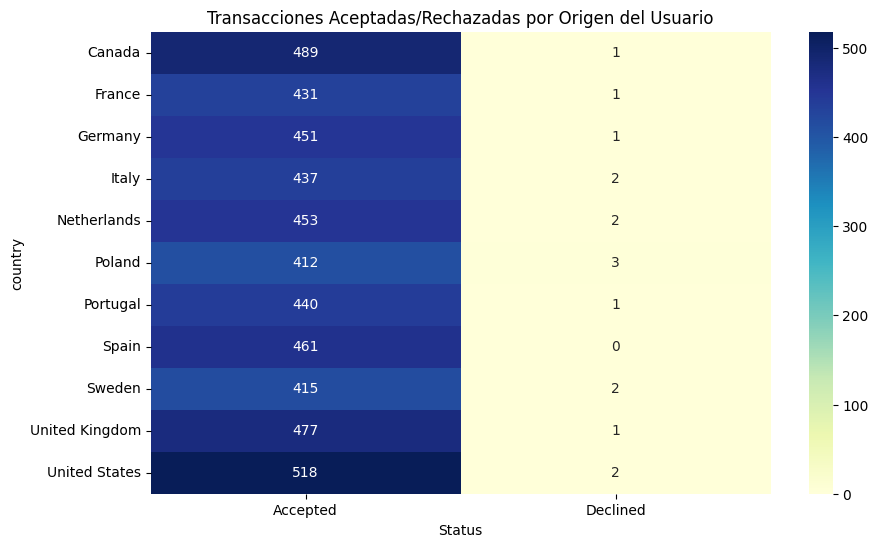

In [24]:
# Heatmap de País vs Estado de Transacción
plt.figure(figsize=(10, 6))
ct = pd.crosstab(df_last_transaction['country'], df_last_transaction['Status'])
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Transacciones Aceptadas/Rechazadas por Origen del Usuario')
plt.show()

#### Interpretación: Segun el heatmap, pareceria no haber una relacion directa entre el pais de origen del usuario y las transacciones no aceptadas.

### #6. Tres variables combinades

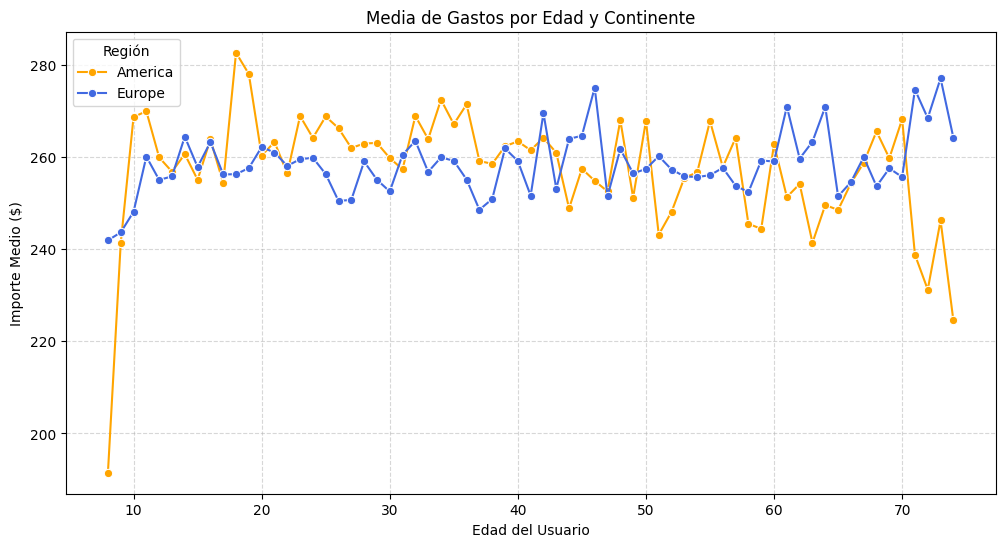

In [25]:
# Scatter plot con Edad, Importe y Origen del usuario
# 1. Filtramos los datos para incluir solo Europa y América
# Usamos el DataFrame que contiene la información de transacciones y continentes
df_filtered = u_t[u_t['Continent'].isin(['Europe', 'America'])]

# 2. Agrupar por edad de last transaction y continente para obtener la media del importe
df_media_gastos = df_filtered.groupby(['age_at_transaction', 'Continent'])['amount'].mean().reset_index()

# 3. Creamos la visualización
plt.figure(figsize=(12, 6))

# Usamos lineplot para ver la progresión de la media
sns.lineplot(
    data=df_media_gastos, 
    x='age_at_transaction', 
    y='amount', 
    hue='Continent', 
    marker='o',
    palette={'Europe': 'royalblue', 'America': 'orange'}
)
plt.title('Media de Gastos por Edad y Continente')
plt.xlabel('Edad del Usuario')
plt.ylabel('Importe Medio ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Región')

plt.show()

#### Interpretación: La media de gastos realizados por usuarios Americanos supera a la de los usuarios Europeos en casi todas las edades, excepto entre los 40 y 50 y mayores a 60, donde el patron parece intercambiarse.

### Si la misma visualizacion la hacemos por rango de edad durante la ultima transaccion (Visualizacion siguiente), observamos que sin importar el rango de edad, los usurios de America tienen un ticket medio mayor al de los Europeos, siendo los de 30-40, los que mas gastan. Los usuarios europeos con mayores tickets medio, en cambio se segmentan entre los de la decada de los 30 y mayores a 50.

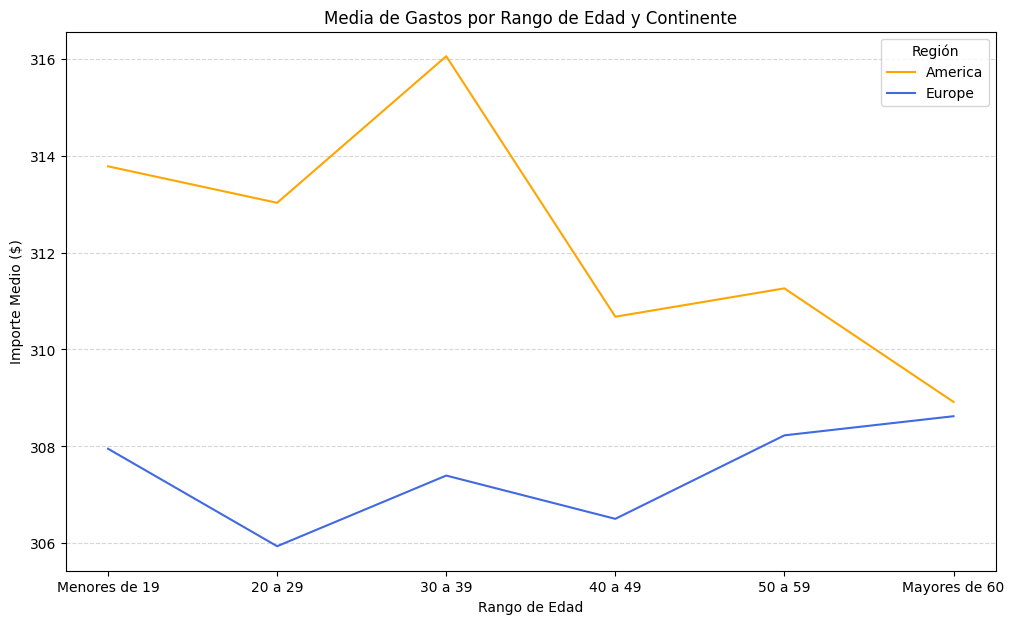

In [28]:
# 1. Definir los límites y las etiquetas de los rangos
bins = [0, 19, 29, 39, 49, 59, 120]
labels = ['Menores de 19', '20 a 29', '30 a 39', '40 a 49', '50 a 59', 'Mayores de 60']

# 2. Crear la columna de rango de edad en el DataFrame original
df_trans_users['age_range'] = pd.cut(
    u_t['age_at_transaction'], 
    bins=bins, 
    labels=labels, 
    include_lowest=False
)

# 3. Filtrar por continentes y calcular la media por rango
df_filtered = df_trans_users[df_trans_users['Continent'].isin(['Europe', 'America'])]
df_grouped = df_filtered.groupby(['age_range', 'Continent'], observed=False)['amount'].mean().reset_index()

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=df_grouped, 
    x='age_range', 
    y='amount', 
    hue='Continent', 
    palette={'Europe': 'royalblue', 'America': 'orange'}
)

# Configuración estética
plt.title('Media de Gastos por Rango de Edad y Continente')
plt.xlabel('Rango de Edad')
plt.ylabel('Importe Medio ($)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Región')

plt.show()

### #7. Crea un Pairplot (Relaciones múltiples)

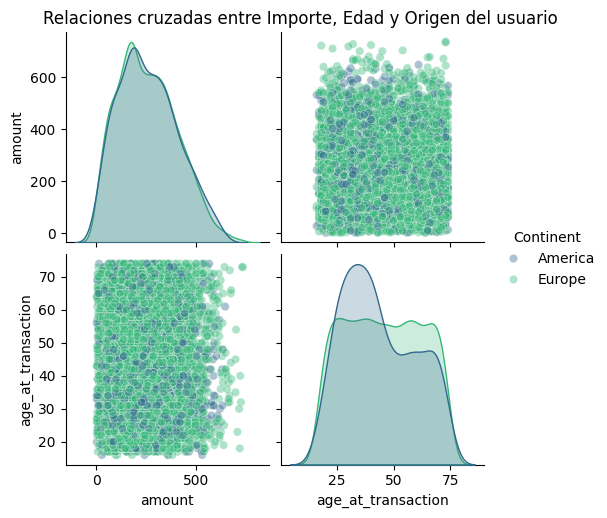

In [41]:
# Seleccionamos solo las columnas de interés para el análisis
df_pairplot = df_last_transaction[['amount', 'age_at_transaction', 'Status', 'Continent']]

# Eliminamos valores nulos
df_pairplot = df_pairplot.dropna()

# Generación del Pairplot
sns.pairplot(
    data=df_pairplot, 
    hue='Continent', 
    kind = 'scatter',
    palette="viridis",
    diag_kind='kde', # Muestra la distribución de cada variable en la diagonal
    plot_kws={'alpha': 0.4},
    diag_kws={'common_norm': False} # Añade transparencia para ver mejor los clusters
)

plt.suptitle('Relaciones cruzadas entre Importe, Edad y Origen del usuario', y=1.02)
plt.show()

### Interpretacion: La diagonal del Pairplot muestra como heatmap, las relaciones cruzadas entre las variables monto gastado y edad usuario durante la ultima transaccion, donde no se ve una relacion directa entre las mismas. Los cuadrantes fuera de la diagonal, muestran la distribucion independiente de las variables separadas por origen del usuario. A partir de estos cuadrantes podemos observar que el gasto medio para usuarios de ambos continentes es de 250 dolares y la edad de la ultima transaccion esta alrededor de los 40 años para los americanos. Sin embargo para los europeos la distribucion de la edad es uniforme.

In [37]:
df_pairplot

,amount,age_at_transaction,Status,Continent
12073,254.46,39,Accepted,America
68662,335.87,40,Accepted,America
59494,127.09,35,Accepted,America
2069,69.16,54,Accepted,Europe
28617,356.94,30,Accepted,Europe
...,...,...,...,...
87826,507.18,61,Accepted,Europe
14211,494.79,54,Accepted,America
60953,326.23,26,Accepted,Europe
87904,254.55,74,Accepted,America


## Level 2

### 1. Analisis de correlacion entre el preio del producto y las ventas

In [48]:
# Generamos nueva consulta para hacer la correlacion teniendo en cuenta la tabla intermedia que separa 
# el producto en distintas filas asociado a su id de transaccion. Unimos esta tabla a la de productos para saber
#los precios y ventas totales de cada producto 
query = """
SELECT 
    p.id, 
    p.price, 
    COUNT(pt.transaction_id) AS total_sales
FROM products p
LEFT JOIN transaction_products pt ON p.id = pt.Product_id
GROUP BY p.id, p.price;
"""

df_correlation = pd.read_sql(query, engine)


In [49]:
# 1. Eliminar el símbolo de dólar y cualquier espacio
df_correlation['price'] = df_correlation['price'].str.replace('$', '', regex=False).str.strip()

# 2. Convertir la columna a tipo float
df_correlation['price'] = pd.to_numeric(df_correlation['price'], errors='coerce')

# 3. para verificar si quedaron valores nulos tras la conversión
print(df_correlation['price'].isna().sum())

0


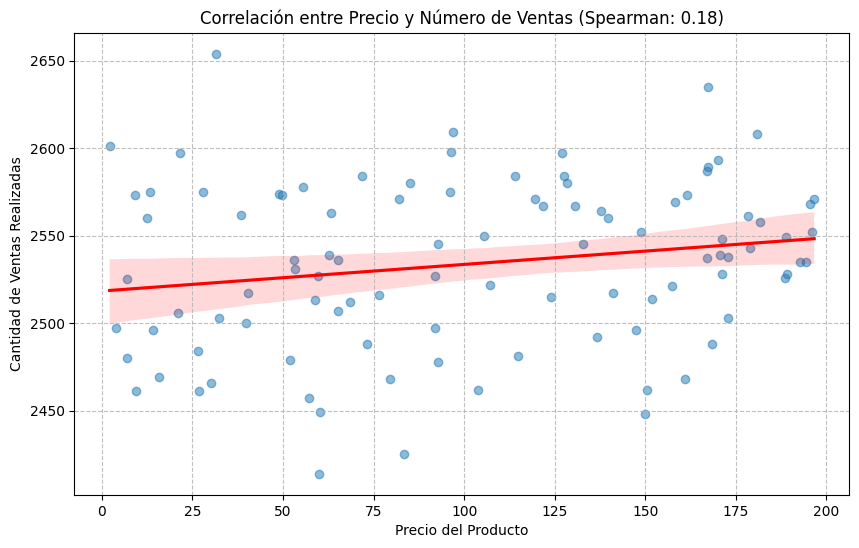

El coeficiente de correlación es: 0.18342760367010438
La correlacion es positiva pero debil


In [50]:
# Calculamos el coeficiente de correlación de Spearman
correlation_value = df_correlation['price'].corr(df_correlation['total_sales'], method='spearman')

# Representación gráfica
plt.figure(figsize=(10, 6))
sns.regplot(data=df_correlation, x='price', y='total_sales', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title(f'Correlación entre Precio y Número de Ventas (Spearman: {correlation_value:.2f})')
plt.xlabel('Precio del Producto')
plt.ylabel('Cantidad de Ventas Realizadas')
plt.grid(True, linestyle='--', alpha=0.8)
plt.show()

print(f"El coeficiente de correlación es: {correlation_value}")
if correlation_value > 0.30:
    print("La correlacion es positiva y fuerte: Las ventas aumentan cuando el precio del producto es mas caro")
elif correlation_value < 0.30 and correlation_value > 0:
    print("La correlacion es positiva pero debil")
else:
    print("La correlacion es negativa")


Podria decirse que a mayor precio del producto, mayores son las ventas. Contamos con productos premium.

In [52]:
# cols_interes = ['amount', 'age_at_transaction']
# df_corr = df_last_transaction[cols_interes].dropna()

# # 2. Cálculo de la matriz de correlación
# # Se utiliza el método de Pearson por defecto: $r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$
# matriz_correlacion = df_corr.corr()

# # 3. Visualización con Heatmap
# plt.figure(figsize=(10, 8))

# sns.heatmap(
#     matriz_correlacion, 
#     annot=True,       # Muestra los valores numéricos dentro de las celdas
#     fmt=".2f",        # Formato de dos decimales
#     cmap='coolwarm',  # Escala de colores (azul para negativa, rojo para positiva)
#     center=0,         # El color neutro se sitúa en el cero
#     linewidths=.5, 
#     cbar_kws={"shrink": .8}
# )

# plt.title('Matriz de Correlación de Variables del Sprint 4')
# plt.show()

### 2. Jointplot para explorar la relacion entre dos variables

In [53]:
df_plot = prod[['Price', 'Weight']]
df_plot

,Price,Weight
0,161.11,1.0
1,119.52,2.4
2,40.43,3.0
3,49.70,2.7
4,181.60,2.1
...,...,...
95,6.90,2.7
96,20.92,2.1
97,65.25,1.0
98,38.33,2.0


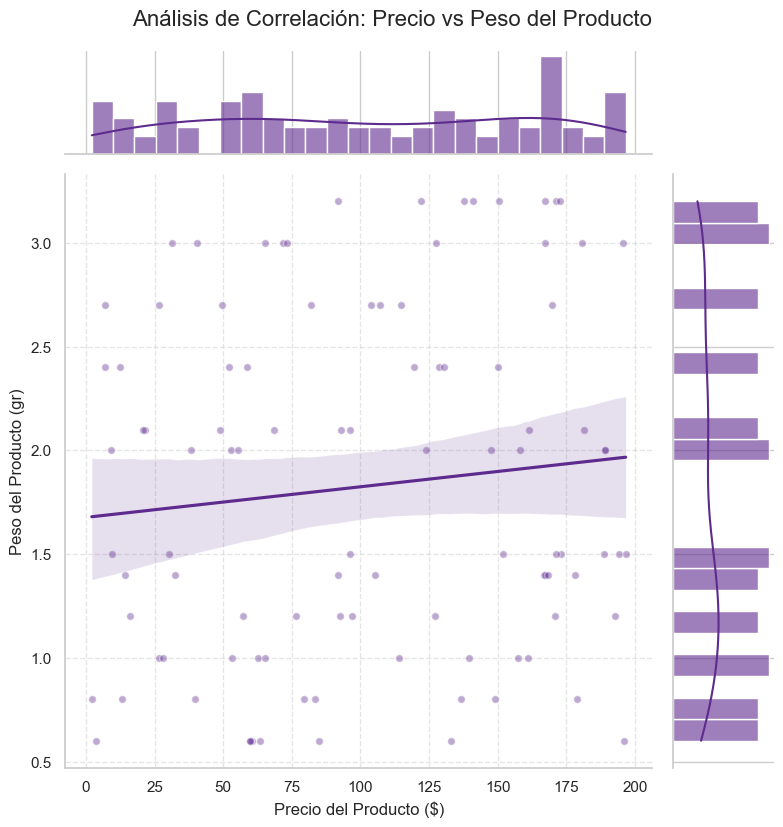

In [54]:
# 1.Filtramos los datos para asegurar que no haya Nones ni NaNs
df_plot = prod[['Price', 'Weight']].dropna()

# Verificación si el dataframe está vacío
if df_plot.empty:
    print("Error: El DataFrame 'prod' está vacío o todas sus celdas son NaN.")
else:
    # Configuramos el estilo
    sns.set_theme(style="whitegrid")
    joint_plot = sns.jointplot(
        data=df_plot, 
        x='Price', 
        y='Weight',
        kind='reg',
        color='#5d2a8e',
        height=8,
        ratio=5,
        marginal_kws=dict(bins=25, fill=True, alpha=0.6),
        scatter_kws={'alpha': 0.4, 's': 30, 'edgecolor': 'w'}
    )

    # Títulos
    joint_plot.figure.suptitle('Análisis de Correlación: Precio vs Peso del Producto', fontsize=16, y=1.03)
    joint_plot.set_axis_labels('Precio del Producto ($)', 'Peso del Producto (gr)', fontsize=12)

    # Cuadrícula
    joint_plot.ax_joint.grid(True, linestyle='--', alpha=0.5)

    plt.show()

#### Interpretacion: Como puede observarse en la represntacion superior, el precio de los productos varia entre myor a 0 y 200 dolares. El numero de productos se concentran en los de mayor y menor precio, mientras que hay menos productos con precios intermedios. El peso de los productos varia uniformemente entre 0.5 a 3.5 gramos. En la grafica central, observamos que pareceria existir una relacion positiva muy debil entre ambas variables. Es decir, a mayor peso del producto, mas caro es el precio. Sin embargo, la alta dispersion de los puntos, requeriria un analisis de correlacion estadistico.